# Full Data Science Project: Iris Classification + FastAPI Deployment

## Objective
Develop a full data science project from data collection and preprocessing to model deployment using FastAPI.

## Deliverables
- Data Collection (Iris dataset)
- Preprocessing
- Model Training
- Evaluation
- Model Saving
- FastAPI Deployment Code
- API Testing Example


## 1) Import Libraries

In [ ]:
import pickle
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt


## 2) Data Collection
We use the built-in Iris dataset from scikit-learn.

In [ ]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 3) Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (120, 4)
Test shape: (30, 4)


## 4) Preprocessing + Model (Pipeline)
We use:
- StandardScaler (feature scaling)
- Logistic Regression (classification model)

In [ ]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=200))
])

model

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=200))])

## 5) Train the Model

In [ ]:
model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


## 6) Model Evaluation

In [ ]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Test Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 7) Confusion Matrix Visualization

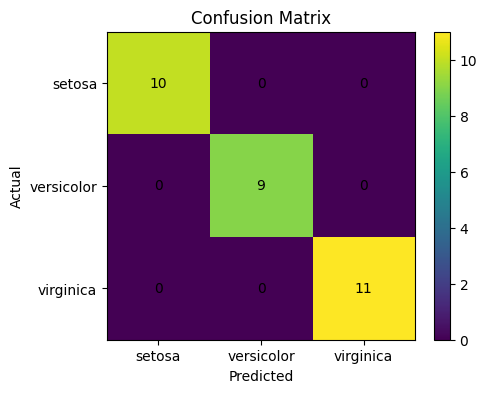

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1,2], iris.target_names)
plt.yticks([0,1,2], iris.target_names)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## 8) Save the Trained Model
We save the entire pipeline (scaler + classifier) into a `.pkl` file.

In [ ]:
with open("iris_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as iris_model.pkl")

Model saved as iris_model.pkl


# 9) Deployment Using FastAPI

Below is the full FastAPI code you should save as `app.py` in the same folder.

### Install Requirements
```bash
pip install fastapi uvicorn scikit-learn pandas numpy
```

### Run the API
```bash
uvicorn app:app --reload
```

### Open Swagger UI
http://127.0.0.1:8000/docs


In [ ]:
# --------------------
# FASTAPI DEPLOYMENT CODE (SAVE AS app.py)
# --------------------

fastapi_code = '''
import pickle
import numpy as np
from fastapi import FastAPI
from pydantic import BaseModel

# Load trained model
with open("iris_model.pkl", "rb") as f:
    model = pickle.load(f)

app = FastAPI(title="Iris Flower Classification API")

class IrisInput(BaseModel):
    sepal_length: float
    sepal_width: float
    petal_length: float
    petal_width: float

@app.get("/")
def home():
    return {"message": "Iris Model API is running!"}

@app.post("/predict")
def predict(data: IrisInput):
    features = np.array([[
        data.sepal_length,
        data.sepal_width,
        data.petal_length,
        data.petal_width
    ]])

    prediction = model.predict(features)[0]
    probs = model.predict_proba(features)[0].tolist()

    class_names = ["setosa", "versicolor", "virginica"]

    return {
        "prediction_class": class_names[prediction],
        "prediction_index": int(prediction),
        "probabilities": {
            "setosa": probs[0],
            "versicolor": probs[1],
            "virginica": probs[2]
        }
    }
'''

print(fastapi_code)


import pickle
import numpy as np
from fastapi import FastAPI
from pydantic import BaseModel

# Load trained model
with open("iris_model.pkl", "rb") as f:
    model = pickle.load(f)

app = FastAPI(title="Iris Flower Classification API")

class IrisInput(BaseModel):
    sepal_length: float
    sepal_width: float
    petal_length: float
    petal_width: float

@app.get("/")
def home():
    return {"message": "Iris Model API is running!"}

@app.post("/predict")
def predict(data: IrisInput):
    features = np.array([[
        data.sepal_length,
        data.sepal_width,
        data.petal_length,
        data.petal_width
    ]])

    prediction = model.predict(features)[0]
    probs = model.predict_proba(features)[0].tolist()

    class_names = ["setosa", "versicolor", "virginica"]

    return {
        "prediction_class": class_names[prediction],
        "prediction_index": int(prediction),
        "probabilities": {
            "setosa": probs[0],
            "versicolor": probs[1],
    

## 10) Example API Request
After running the API, test `/predict` with this JSON:

```json
{
  "sepal_length": 5.1,
  "sepal_width": 3.5,
  "petal_length": 1.4,
  "petal_width": 0.2
}
```

Expected Output Example:
```json
{
  "prediction_class": "setosa",
  "prediction_index": 0,
  "probabilities": {
    "setosa": 0.98,
    "versicolor": 0.01,
    "virginica": 0.01
  }
}
```